In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.6
NumPy: 2.5.3


In [2]:
current_path = Path.cwd()

print("Current working directory:")
print(current_path)

Current working directory:
f:\4\Hoc may co ban\WaterQualityProject\ai-models\colab


In [3]:
possible_paths = [
    Path("../data/water_potability.csv"),
    Path("ai-models/data/water_potability.csv"),
    Path("../ai-models/data/water_potability.csv"),
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Không tìm thấy water_potability.csv")

print("Dataset path:", data_path.resolve())

Dataset path: F:\4\Hoc may co ban\WaterQualityProject\ai-models\data\water_potability.csv


In [4]:
df = pd.read_csv(data_path)

print("Đọc dataset thành công.")
print("Kích thước dataset:", df.shape)

Đọc dataset thành công.
Kích thước dataset: (3276, 10)


In [5]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing": missing_values,
    "Missing_Percent": (missing_values / len(df) * 100).round(2)
})

missing_table

,Missing,Missing_Percent
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00
Potability,0,0.00


In [8]:
duplicate_count = df.duplicated().sum()

print("Số dòng bị trùng:", duplicate_count)

Số dòng bị trùng: 0


In [9]:
target_counts = df["Potability"].value_counts().sort_index()

target_percent = (
    df["Potability"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percent": target_percent
})

target_summary

,Count,Percent
Potability,,
0,1998,60.99
1,1278,39.01


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


## EDA 4 - Correlation Heatmap

Mục tiêu:
- Phân tích mức độ tương quan giữa các đặc trưng số.
- Xem đặc trưng nào có quan hệ mạnh hoặc yếu với `Potability`.
- Kiểm tra khả năng tồn tại các đặc trưng có tương quan cao với nhau.

In [11]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


In [12]:
target_correlation = (
    correlation_matrix["Potability"]
    .drop("Potability")
    .sort_values(key=abs, ascending=False)
)

target_correlation

Solids             0.033743
Organic_carbon    -0.030001
Chloramines        0.023779
Sulfate           -0.023577
Hardness          -0.013837
Conductivity      -0.008128
Trihalomethanes    0.007130
ph                -0.003556
Turbidity          0.001581
Name: Potability, dtype: float64

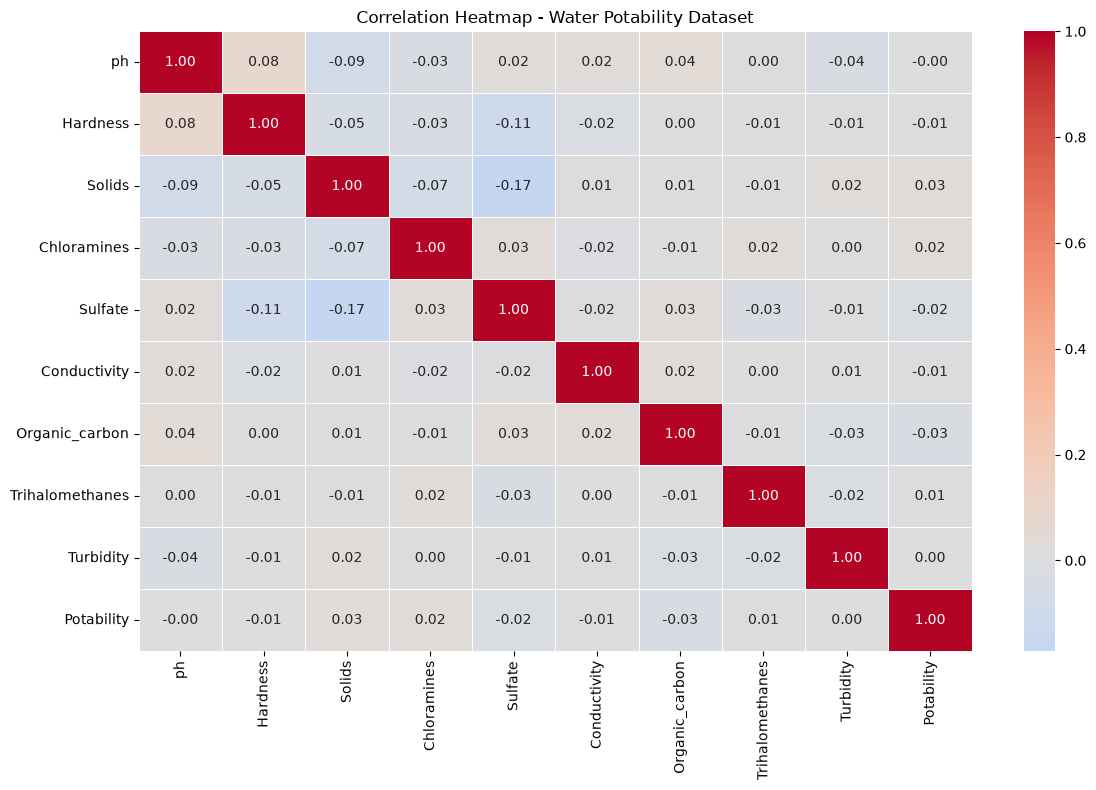

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Water Potability Dataset")
plt.tight_layout()
plt.show()

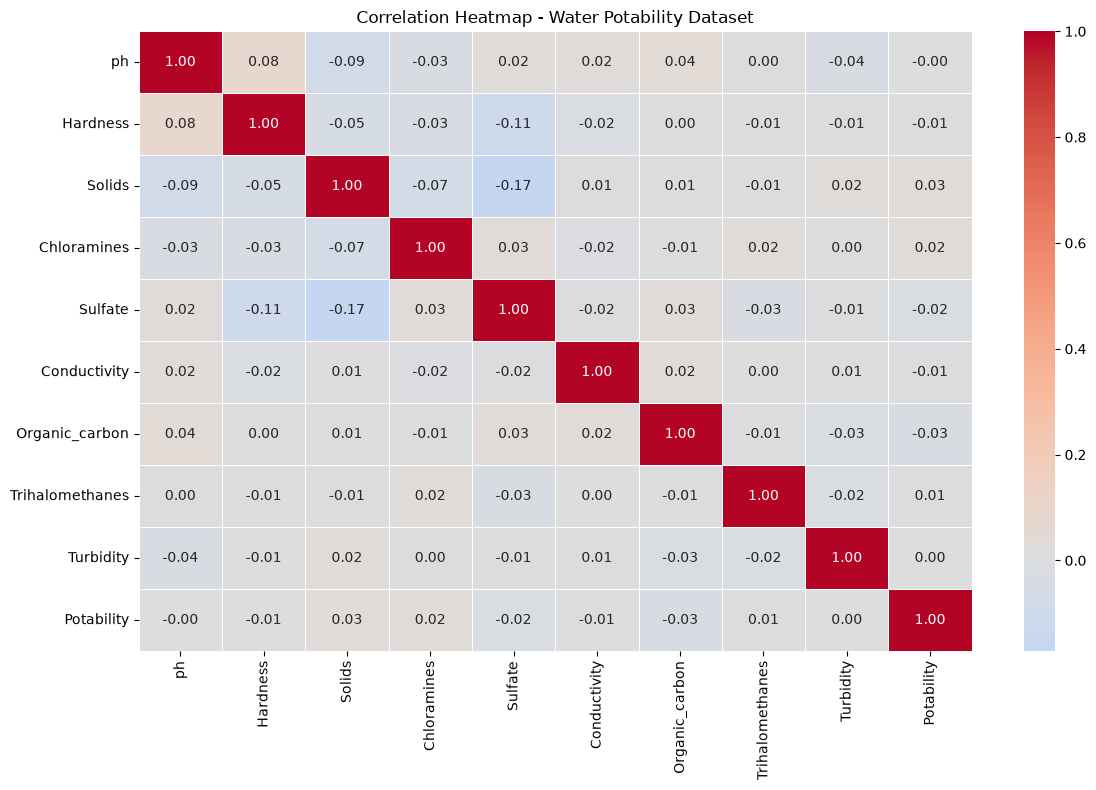

Đã lưu hình tại:
F:\4\Hoc may co ban\WaterQualityProject\docs\figures\correlation_heatmap_tv2.png


In [14]:
project_root = data_path.resolve().parents[2]

figures_dir = project_root / "docs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

heatmap_path = figures_dir / "correlation_heatmap_tv2.png"

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Water Potability Dataset")
plt.tight_layout()

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu hình tại:")
print(heatmap_path)

### Nhận xét Correlation Heatmap

**1. Biểu đồ cho thấy gì?**

Ma trận tương quan cho thấy phần lớn các đặc trưng trong dataset có mức tương quan tuyến tính thấp với nhau.

Đối với biến mục tiêu `Potability`, tất cả các hệ số tương quan đều có giá trị tuyệt đối rất nhỏ:

- `Solids`: 0.0337
- `Organic_carbon`: -0.0300
- `Chloramines`: 0.0238
- `Sulfate`: -0.0236
- `Hardness`: -0.0138
- `Conductivity`: -0.0081
- `Trihalomethanes`: 0.0071
- `ph`: -0.0036
- `Turbidity`: 0.0016

Trong đó, `Solids` có tương quan dương lớn nhất với `Potability`, nhưng hệ số chỉ khoảng 0.034.  
`Organic_carbon` có tương quan âm lớn nhất, khoảng -0.030.

Giữa các đặc trưng đầu vào cũng không xuất hiện cặp biến nào có tương quan tuyến tính quá cao. Một trong các cặp đáng chú ý hơn là `Solids` và `Sulfate` với hệ số tương quan khoảng -0.17, nhưng mức này vẫn tương đối thấp.

**2. Ý nghĩa đối với bài toán**

Kết quả cho thấy không có một đặc trưng đơn lẻ nào có mối quan hệ tuyến tính mạnh với khả năng uống được của nước.

Điều này cho thấy bài toán phân loại `Potability` có thể không được giải quyết tốt chỉ bằng cách xem xét từng đặc trưng riêng lẻ hoặc dựa hoàn toàn vào quan hệ tuyến tính.

Tuy nhiên, hệ số tương quan thấp không có nghĩa là các đặc trưng không có giá trị dự đoán. Các đặc trưng có thể tương tác với nhau hoặc tồn tại các quan hệ phi tuyến mà hệ số tương quan Pearson không thể hiện rõ.

**3. Quyết định xử lý tiếp theo**

- Chưa loại bỏ đặc trưng nào chỉ dựa trên Correlation Heatmap.
- Tiếp tục giữ 9 đặc trưng đầu vào để đánh giá trong quá trình huấn luyện mô hình.
- Tiếp tục phân tích sự phân bố của các đặc trưng theo từng lớp `Potability`.
- Tiếp tục kiểm tra mối quan hệ giữa các đặc trưng bằng các biểu đồ khác.
- Missing values sẽ được xử lý trong bước preprocessing bằng pipeline phù hợp để tránh data leakage.
- Các mô hình tuyến tính và phi tuyến sẽ được so sánh để đánh giá liệu quan hệ giữa các đặc trưng và `Potability` có thể được khai thác tốt hơn bởi các mô hình khác nhau hay không.